# L6 demo: validating a live plant stream

This notebook connects to a running plant, collects a few minutes of its telemetry,
and puts that telemetry through the two ideas of this session: a schema used as a
gate, and a windowed aggregate computed in event time.

The feed is the same one Assignment **A3** collects from, and it is live. Nobody has
cleaned it, the numbers are different every time you run this, and some of what
arrives is wrong or late. Read the printed output rather than trusting a number
written in a markdown cell, because there are none.


## Run this first on Colab

Colab starts from its own preinstalled environment rather than this course's `uv`
environment, so run the cell below before anything else. It installs what this
notebook needs and Colab does not already have. Outside Colab it does nothing, so
you can run it or skip it.


In [1]:
# Run this first on Colab. Anywhere else this cell does nothing.
#
# Only genuinely missing packages are installed, so Colab's own versions of
# everything it already ships are left alone.
#
# Generated by tools/colab_setup.py from this notebook's imports. Edit that.
import importlib.util
import subprocess
import sys

REQUIREMENTS = {
    "matplotlib": "matplotlib",
    "paho": "paho-mqtt",
    "pandas": "pandas",
    "pandera.pandas": "pandera",
}


def _missing(module):
    try:
        return importlib.util.find_spec(module) is None
    except ModuleNotFoundError:  # the parent package is absent
        return True


if "google.colab" in sys.modules:
    need = sorted({pip for mod, pip in REQUIREMENTS.items() if _missing(mod)})
    if need:
        print("installing:", " ".join(need))
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *need], check=True)
    print("Colab setup done." if need else "Colab: nothing to install.")


installing: paho-mqtt pandera
Colab setup done.


## 1. The plant

The [Tennessee Eastman process](https://doi.org/10.1016/0098-1354(93)80018-I) is a
chemical plant published by Downs and Vogel in 1993 as a control and monitoring
benchmark, and it has been one ever since. Four gaseous reactants (A, C, D, E) plus
an inert (B) and a byproduct (F) go in; two liquid products (G and H) come out.

![The Tennessee Eastman process flowsheet](https://kitchingroup.cheme.cmu.edu/f26-06763/_images/tep-screenshot.png)

*Figure from [Lyu, Botcha, Kulkarni, Pagaria, Alves, Sunshine, and Kitchin
(2026)](https://chemrxiv.org/doi/abs/10.26434/chemrxiv.10001628/v1). You can run the
simulator yourself at [TEP Studio](https://kitchingroup.cheme.cmu.edu/tep-rust/studio/).*

Follow the flowsheet left to right. Feeds A, D and E and a combined A/B/C stream
enter a **reactor**, which is where the reaction happens and which is cooled by a
water coil. Its vapour goes to a **condenser**, then to a **separator** that splits
the condensed liquid from the gas. The gas is recycled through a **compressor** back
to the reactor, with a small **purge** stream bleeding off so the inert B does not
accumulate until the plant chokes. The separator's liquid drops into a **stripper**,
which boils the light components back out with steam, and what leaves the bottom of
the stripper is the product.

Three blocks on the diagram are labelled Analyzer, on the reactor feed, on the purge
and on the product. Those are gas chromatographs, and they are the reason this plant
is interesting to a streaming lecture: they do not report continuously. They take a
sample, run it, and report a composition some minutes later, so their readings are
both infrequent and stale by a known amount.

The stream carries 53 tags, which is the whole instrument list:

| Tags | What they are |
|---|---|
| `XMEAS_1` to `XMEAS_6` | feed flows and the recycle, in kscmh or kg/hr |
| `XMEAS_7` to `XMEAS_9` | reactor pressure, level, temperature |
| `XMEAS_10` | purge rate |
| `XMEAS_11` to `XMEAS_14` | separator temperature, level, pressure, underflow |
| `XMEAS_15` to `XMEAS_19` | stripper level, pressure, underflow, temperature, steam |
| `XMEAS_20` to `XMEAS_22` | compressor work and the two cooling water outlets |
| `XMEAS_23` to `XMEAS_28` | reactor feed composition, A to F, from an analyser |
| `XMEAS_29` to `XMEAS_36` | purge composition, A to H, from an analyser |
| `XMEAS_37` to `XMEAS_41` | product composition, D to H, from an analyser |
| `XMV_1` to `XMV_12` | the twelve valve positions the controller writes |

So 34 of the 53 are continuous instruments, sampled and reported every cycle, and 19
are analyser channels that report on their own slower schedule. Section 7 measures
that split from the data instead of taking this paragraph's word for it.


## 2. Collect from the live stream

The plant publishes to an MQTT broker over WebSockets on port 443, which is the one
port that is open everywhere. Three topics: `plant/tep/birth` carries the tag
dictionary and is retained, so you get it the moment you subscribe; `plant/tep/telemetry`
carries the readings; `plant/tep/event` carries plant restarts.

The cell below does the one thing a collector should do, which is write down exactly
what arrived, in the order it arrived, wrapped in an envelope recording when your
machine saw it. It does not sort, deduplicate, drop, or parse. Those are decisions,
and decisions belong in the pipeline where you can see and test them.

The file is cached under `data/`, so running this notebook a second time costs
nothing and works with the plant switched off. Delete the file to collect afresh.


In [2]:
import datetime
import json
import pathlib
import time

import paho.mqtt.client as mqtt

HOST, PORT, WS_PATH = "kitchin-services.cheme.cmu.edu", 443, "/mqtt"
TOPIC = "plant/#"
SECONDS = 180
RAW = pathlib.Path("data") / "l06-stream.ndjson"


def collect(seconds=SECONDS, out=RAW):
    """Append one line per message for `seconds`, then stop."""
    out.parent.mkdir(parents=True, exist_ok=True)
    handle = out.open("a", encoding="utf-8")
    count = 0

    def on_connect(client, userdata, flags, reason_code, properties=None):
        client.subscribe(TOPIC, qos=0)

    def on_message(client, userdata, msg):
        nonlocal count
        # The payload goes through byte for byte. Parsing and re-serializing it
        # here would reorder keys and change spacing, and anything computed over
        # the exact bytes the broker sent would stop matching.
        seen = (datetime.datetime.now(datetime.timezone.utc)
                .isoformat(timespec="milliseconds").replace("+00:00", "Z"))
        handle.write('{"receivedAt":"%s","topic":"%s","payload":%s}\n'
                     % (seen, msg.topic, msg.payload.decode("utf-8", errors="replace")))
        count += 1

    client = mqtt.Client(mqtt.CallbackAPIVersion.VERSION2, transport="websockets")
    client.ws_set_options(path=WS_PATH)
    client.tls_set()
    client.on_connect, client.on_message = on_connect, on_message
    client.connect(HOST, PORT, keepalive=60)
    client.loop_start()
    time.sleep(seconds)
    client.loop_stop()
    client.disconnect()
    handle.close()
    return count


if RAW.exists():
    print(f"reusing the capture already in {RAW}")
else:
    print(f"collecting for {SECONDS} s ...")
    print(f"{collect()} messages")

lines = RAW.read_text().splitlines()
print(f"{len(lines)} lines, {RAW.stat().st_size / 1e6:.2f} MB")
print(lines[0][:220])

collecting for 180 s ...
146 messages
146 lines, 0.92 MB
{"receivedAt":"2026-09-14T20:22:38.030Z","topic":"plant/tep/birth","payload":{"type":"birth","plant":"tep","schema":"opcua-datavalue/1","accelerationFactor":144,"plantEpoch":"2026-09-09T19:00:37.003Z","sampleIntervalSeco


## 3. The contract: the birth message

A stream of numbers with no dictionary is undecodable, so the publisher sends one
**birth message** at startup and the broker retains it. It says how fast the
simulation runs against wall clock, when plant time started, how often a sample is
taken, and what every tag is.

That message is the **data contract** for this feed. Section 5 builds the validation
schema out of it rather than typing the same facts a second time, which is the point
of having a contract at all: two hand-written copies of the truth will disagree, and
the one you are not looking at is the one that is wrong.


In [3]:
import pandas as pd

messages = [json.loads(line) for line in lines]
birth = next(m["payload"] for m in messages if m["payload"].get("type") == "birth")
telemetry = [m for m in messages if m["topic"].endswith("/telemetry")]

print({k: v for k, v in birth.items() if k != "tags"})
print(f"{len(birth['tags'])} tags, {len(telemetry)} telemetry messages")

contract = pd.DataFrame(birth["tags"]).rename(columns={"name": "tag"})
# A capture short enough to miss every analyser refresh would have no such
# column at all, and the code below expects one either way.
for column in ("analyserIntervalHours", "deadTimeHours"):
    if column not in contract:
        contract[column] = pd.NA
contract

{'type': 'birth', 'plant': 'tep', 'schema': 'opcua-datavalue/1', 'accelerationFactor': 144, 'plantEpoch': '2026-09-09T19:00:37.003Z', 'sampleIntervalSeconds': 180}
53 tags, 145 telemetry messages


,tag,description,unit,analyserIntervalHours,deadTimeHours
0,XMEAS_1_A_feed,A Feed (stream 1),kscmh,NaN,NaN
1,XMEAS_2_D_feed,D Feed (stream 2),kg/hr,NaN,NaN
2,XMEAS_3_E_feed,E Feed (stream 3),kg/hr,NaN,NaN
3,XMEAS_4_total_feed,A and C Feed (stream 4),kscmh,NaN,NaN
4,XMEAS_5_recycle_flow,Recycle Flow (stream 8),kscmh,NaN,NaN
5,XMEAS_6_reactor_feed_rate,Reactor Feed Rate (stream 6),kscmh,NaN,NaN
6,XMEAS_7_reactor_pressure,Reactor Pressure,kPa gauge,NaN,NaN
7,XMEAS_8_reactor_level,Reactor Level,%,NaN,NaN
8,XMEAS_9_reactor_temperature,Reactor Temperature,Deg C,NaN,NaN
9,XMEAS_10_purge_rate,Purge Rate (stream 9),kscmh,NaN,NaN


In [ ]:
# The units the contract declares, and how many tags carry each. The schema in
# section 5 keys its range checks on exactly this list.
print(contract.groupby("unit").size().sort_values(ascending=False).to_string())

# The analyser channels announce themselves: an interval and a dead time, both
# in plant hours. Everything else reports every cycle.
analysers = contract[contract["analyserIntervalHours"].notna()]
print(f"\n{len(analysers)} analyser channels, {len(contract) - len(analysers)} continuous")
print(analysers.groupby(["analyserIntervalHours", "deadTimeHours"]).size().to_string())

## 4. Decode: nested JSON to a tidy table

Each telemetry message is one sample of the whole plant: an envelope with a sequence
number, a publish timestamp and an `isHistorical` flag, wrapping an array of 53
metrics. Each metric is an OPC UA `DataValue`, which is a value plus a status code
plus the timestamp of the reading itself.

So there are **three clocks** on every row, and they answer three different questions:

- `sourceTimestamp`, the **event time**, when the instrument took the reading.
- `timestamp`, the **publish time**, when the historian put the message on the wire.
- `receivedAt`, the **processing time**, when your machine saw it.

`pd.json_normalize` flattens one level and copies the envelope fields down onto every
metric, which is what `record_path` and `meta` do. Note that the `meta` columns come
back as `object`, so `isHistorical` is Python `bool` in an object column rather than a
boolean dtype, and has to be cast.


In [4]:
records = [{"receivedAt": m["receivedAt"], **m["payload"]} for m in telemetry]
df = pd.json_normalize(
    records,
    record_path="metrics",
    meta=["seq", "timestamp", "isHistorical", "receivedAt"],
)
df = df.rename(columns={"name": "tag", "statusCode": "status",
                        "sourceTimestamp": "event_time", "timestamp": "server_time",
                        "receivedAt": "received_at", "isHistorical": "is_historical"})

# Pin the timestamp resolution rather than taking the default. pandas 2 parses to
# nanoseconds and pandas 3 to microseconds, so a schema that names a dtype passes
# on one machine and fails on the next. The wire format is milliseconds.
STAMP = "datetime64[ms, UTC]"
for column in ("event_time", "server_time", "received_at"):
    df[column] = pd.to_datetime(df[column], utc=True, format="ISO8601").astype(STAMP)
df["is_historical"] = df["is_historical"].astype(bool)
df["seq"] = df["seq"].astype(int)

# The unit comes from the contract, not from the telemetry, which never repeats it.
df = df.merge(contract[["tag", "unit"]], on="tag", how="left")

print(f"{len(df):,} readings from {len(telemetry):,} messages")
print(df.dtypes.to_string())
df.head()

7,685 readings from 145 messages
tag                           object
value                        float64
status                        object
event_time       datetime64[ms, UTC]
seq                            int64
server_time      datetime64[ms, UTC]
is_historical                   bool
received_at      datetime64[ms, UTC]
unit                          object


,tag,value,status,event_time,seq,server_time,is_historical,received_at,unit
0,XMEAS_1_A_feed,0.318104,Good,2028-09-06 23:55:05.012000+00:00,208,2028-09-06 23:55:05.012000+00:00,False,2026-09-14 20:22:38.475000+00:00,kscmh
1,XMEAS_2_D_feed,3650.108123,Good,2028-09-06 23:55:05.012000+00:00,208,2028-09-06 23:55:05.012000+00:00,False,2026-09-14 20:22:38.475000+00:00,kg/hr
2,XMEAS_3_E_feed,4411.359959,Good,2028-09-06 23:55:05.012000+00:00,208,2028-09-06 23:55:05.012000+00:00,False,2026-09-14 20:22:38.475000+00:00,kg/hr
3,XMEAS_4_total_feed,9.593450,Good,2028-09-06 23:55:05.012000+00:00,208,2028-09-06 23:55:05.012000+00:00,False,2026-09-14 20:22:38.475000+00:00,kscmh
4,XMEAS_5_recycle_flow,27.088640,Good,2028-09-06 23:55:05.012000+00:00,208,2028-09-06 23:55:05.012000+00:00,False,2026-09-14 20:22:38.475000+00:00,kscmh


## 5. A schema built from the contract, used as a gate

Two schemas, because there are two different questions and conflating them is how a
validation suite ends up rejecting data it should have kept.

`feed_schema` asks **did the publisher keep its promises**: every tag is one the
contract declared, every status is one of the three OPC UA codes, every value that is
present is inside the physical range for its unit, and nothing was published before it
was measured. A failure here is a bug on the other side of the wire.

`clean_schema` asks **is this fit to average**: a real value, a `Good` status, and one
row per tag per reading. A failure here is normal and expected, and the answer is not
to reject the feed, it is to route the offending rows somewhere else, which section 6
does.

Both are generated from `contract`. The tag set, the unit list and the allowed
statuses are read out of the birth message, so if the plant adds an instrument
tomorrow the schema knows about it, and if it adds a unit nobody has written a range
for, the assertion below fails loudly instead of waving the values through.


In [5]:
import pandera.pandas as pa

# Physical bounds per unit, wide enough that a plausible reading passes and an
# impossible one does not. A composition outside 0 to 100 mole % is not a
# measurement, it is an artifact of whatever produced it.
UNIT_RANGE = {
    "Mole %": (0.0, 100.0),
    "%": (0.0, 100.0),
    "Deg C": (0.0, 200.0),
    "kPa gauge": (0.0, 4000.0),
    "kscmh": (0.0, 200.0),
    "kg/hr": (0.0, 20000.0),
    "m3/hr": (0.0, 200.0),
    "kW": (0.0, 2000.0),
}
unknown = sorted(set(contract["unit"]) - set(UNIT_RANGE))
assert not unknown, f"the contract declares a unit with no range here: {unknown}"

STATUSES = {"Good", "Uncertain_SensorNotAccurate", "Bad_DeviceFailure"}


def in_unit_range(frame):
    """One range per unit, so this is a whole-frame check, not a column check."""
    low = frame["unit"].map(lambda u: UNIT_RANGE[u][0])
    high = frame["unit"].map(lambda u: UNIT_RANGE[u][1])
    return frame["value"].isna() | frame["value"].between(low, high)


def read_before_published(frame):
    """Clock drift check: nothing can be sent before it was measured."""
    return frame["event_time"] <= frame["server_time"]


COLUMNS = {
    "tag": pa.Column(str, pa.Check.isin(set(contract["tag"]))),
    "value": pa.Column(float, nullable=True),
    "status": pa.Column(str, pa.Check.isin(STATUSES)),
    "event_time": pa.Column(STAMP),
    "server_time": pa.Column(STAMP),
    "received_at": pa.Column(STAMP),
    "seq": pa.Column(int, pa.Check.in_range(0, 255)),
    "is_historical": pa.Column(bool),
    "unit": pa.Column(str, pa.Check.isin(set(UNIT_RANGE))),
}
CHECKS = [
    pa.Check(in_unit_range, name="value_inside_the_range_for_its_unit"),
    pa.Check(read_before_published, name="event_time_at_or_before_server_time"),
]

# strict=True rejects a column nobody declared, which is how a silently added
# field gets noticed instead of ignored.
feed_schema = pa.DataFrameSchema(COLUMNS, checks=CHECKS, strict=True)

Run the feed gate first, non-lazily. It stops at the first problem it meets, which
is what a gate in a pipeline should do: fail before the transform stage, not after.

Whether it fails depends on what the plant did while you were listening. The
simulator occasionally emits a composition a hair below zero, which is physically
impossible and a good example of the kind of thing a range check exists to catch.


In [6]:
try:
    feed_schema.validate(df)
    print("the feed kept its contract")
except pa.errors.SchemaError as err:
    print("the feed broke its contract\n")
    print(str(err)[:600])

the feed broke its contract

DataFrameSchema 'None' failed element-wise validator number 0: <Check value_inside_the_range_for_its_unit> failure cases: XMEAS_37_product_D, XMEAS_37_product_D, XMEAS_37_product_D, XMEAS_37_product_D, XMEAS_37_product_D, XMEAS_37_product_D, XMEAS_37_product_D, XMEAS_37_product_D, XMEAS_37_product_D, XMEAS_37_product_D, -0.001992, -0.001992, -0.001992, -0.001992, -0.001992, -0.00571, -0.00571, -0.00571, -0.00571, -0.00571, Good, Good, Good, Good, Good, Good, Good, Good, Good, Good, 2028-09-07 00:49:05.012000+00:00, 2028-09-07 00:49:05.012000+00:00, 2028-09-07 00:49:05.012000+00:00, 2028-09-07 


Now the same idea with `lazy=True`, on the stricter schema. Lazy validation collects
every failure instead of raising on the first, so `err.failure_cases` is a dataframe
you can group and count. That is the difference between "something is wrong" and
"here are the four things that are wrong, and how many rows each one accounts for".


In [7]:
clean_schema = pa.DataFrameSchema(
    dict(COLUMNS,
         value=pa.Column(float, nullable=False),
         status=pa.Column(str, pa.Check.equal_to("Good"))),
    checks=CHECKS,
    unique=["tag", "event_time"],
    strict=True,
)

try:
    clean_schema.validate(df, lazy=True)
    print("every reading is fit to average, which would be a first")
except pa.errors.SchemaErrors as err:
    cases = err.failure_cases
    print(f"{len(cases):,} failure cases over {len(df):,} readings\n")
    print(cases.groupby("check").size().sort_values(ascending=False).to_string())

5,695 failure cases over 7,685 readings

check
multiple_fields_uniqueness             5580
value_inside_the_range_for_its_unit      90
equal_to(Good)                           20
not_nullable                              5


## 6. The confident wrong number, and quarantine

The uniqueness failure is the interesting one, and it is not a bug in the feed.

An analyser reports every 0.1 or 0.25 plant hours, but the historian publishes every
0.05 hours. Between analyses it republishes the last value it has, with the original
`sourceTimestamp` attached, which is exactly right: the tag really does still hold
that value, and the timestamp really does say when it was measured. Take the feed at
face value, though, and you will believe you have five times as many product
composition measurements as you do. Any count, any rate, any "how much data do I
have", and any model that assumes independent samples inherits that factor.

Deduplicating on `(tag, sourceTimestamp)` is what recovers the real number, and it has
to happen before anything else in section 8 or the held republishes look like a flood
of late data.

The two other failures get a different treatment. A `Bad_DeviceFailure` reading has a
null value, so it cannot poison a mean, but it also cannot be counted as a
measurement. An `Uncertain_SensorNotAccurate` reading is the dangerous one: it carries
a perfectly plausible number, and nothing about the number itself tells you the device
did not trust it. Dropping either silently would be the worst option, so both go to a
**quarantine** table with the reason attached, which is a record you can count, plot
and complain about.


In [8]:
low = df["unit"].map(lambda u: UNIT_RANGE[u][0])
high = df["unit"].map(lambda u: UNIT_RANGE[u][1])

reason = pd.Series("", index=df.index, dtype=object)
reason[~df["value"].between(low, high) & df["value"].notna()] = "outside the range for its unit"
# Status last, so a flagged reading is reported as flagged rather than as
# out of range, which is the more specific complaint.
reason[df["status"] != "Good"] = "the device flagged it: " + df["status"]

quarantine = df[reason != ""].assign(reason=reason[reason != ""])
kept = df[reason == ""]

print(quarantine["reason"].value_counts().to_string())
print(f"\nkept {len(kept):,} of {len(df):,} readings")
quarantine.head()

reason
the device flagged it: Uncertain_SensorNotAccurate    15
outside the range for its unit                        10
the device flagged it: Bad_DeviceFailure               5

kept 7,655 of 7,685 readings


,tag,value,status,event_time,seq,server_time,is_historical,received_at,unit,reason
375,XMEAS_5_recycle_flow,27.034489,Uncertain_SensorNotAccurate,2028-09-07 00:16:05.012000+00:00,215,2028-09-07 00:16:05.012000+00:00,False,2026-09-14 20:22:47.225000+00:00,kscmh,the device flagged it: Uncertain_SensorNotAccu...
945,XMV_4_total_feed_flow,60.305538,Uncertain_SensorNotAccurate,2028-09-07 00:46:05.012000+00:00,225,2028-09-07 00:46:05.012000+00:00,False,2026-09-14 20:22:59.725000+00:00,%,the device flagged it: Uncertain_SensorNotAccu...
990,XMEAS_37_product_D,-0.001992,Good,2028-09-07 00:49:05.012000+00:00,226,2028-09-07 00:49:05.012000+00:00,False,2026-09-14 20:23:00.975000+00:00,Mole %,outside the range for its unit
1043,XMEAS_37_product_D,-0.001992,Good,2028-09-07 00:49:05.012000+00:00,227,2028-09-07 00:52:05.012000+00:00,False,2026-09-14 20:23:02.225000+00:00,Mole %,outside the range for its unit
1096,XMEAS_37_product_D,-0.001992,Good,2028-09-07 00:49:05.012000+00:00,228,2028-09-07 00:55:05.012000+00:00,False,2026-09-14 20:23:03.475000+00:00,Mole %,outside the range for its unit


In [9]:
readings = kept.drop_duplicates(subset=["tag", "event_time"]).copy()
print(f"{len(kept):,} rows collapse to {len(readings):,} measurements "
      f"({100 * (1 - len(readings) / len(kept)):.1f}% were republished values)\n")

counted = (kept.groupby("tag").size().rename("rows_received").to_frame()
           .join(readings.groupby("tag").size().rename("measurements")))
counted["published_per_measurement"] = (
    counted.rows_received / counted.measurements).round(2)
counted = counted.sort_values("published_per_measurement")
# The two extremes: a continuous instrument, and a product analyser.
pd.concat([counted.head(3), counted.tail(3)])

7,655 rows collapse to 6,055 measurements (20.9% were republished values)



,rows_received,measurements,published_per_measurement
tag,,,
XMEAS_8_reactor_level,142,142,1.00
XMEAS_10_purge_rate,145,144,1.01
XMEAS_12_separator_level,145,144,1.01
XMEAS_38_product_E,145,30,4.83
XMEAS_40_product_G,145,30,4.83
XMEAS_41_product_H,145,30,4.83


With the flagged and impossible rows quarantined and the republishes collapsed, the
clean schema should now pass. That is the shape worth copying: the gate does not
decide what to do about bad data, it decides whether the data reaching the next stage
is what that stage was promised.


In [10]:
clean_schema.validate(readings, lazy=True)
print(f"{len(readings):,} measurements pass the clean schema")

6,055 measurements pass the clean schema


## 7. Three clocks, and the nineteen analysers

The gap between event time and publish time is not noise, it is a property of the
instrument, and the contract already told you what it is. A tag with an
`analyserIntervalHours` of 0.25 reports every 900 plant seconds while the historian
publishes every 180, so the value on the wire can be up to 900 minus 180 seconds old
before it is refreshed. A continuous tag is never stale at all.

That is a prediction, made from the contract alone, for each of the 53 tags. The cell
below checks it against the measured lag on the messages that were published live.

Staleness is measured on what was published, `kept`, rather than on the deduplicated
`readings`. A held value is at its stalest on the last message that carries it, and
deduplication keeps the first, so measuring after the collapse would report every
analyser as perfectly fresh.


In [11]:
published = kept.assign(
    lag_s=(kept["server_time"] - kept["event_time"]).dt.total_seconds())

sample_s = birth["sampleIntervalSeconds"]
predicted = contract.assign(
    predicted_max_lag_s=(contract["analyserIntervalHours"].astype(float).fillna(0.0)
                         * 3600 - sample_s).clip(lower=0)
)[["tag", "analyserIntervalHours", "predicted_max_lag_s"]]

# Only the live messages: a replayed backlog carries a publish time from when the
# link came back, which is a different story and is section 8's.
live = published[~published["is_historical"]]
observed = live.groupby("tag")["lag_s"].max().rename("observed_max_lag_s")

check = predicted.merge(observed, on="tag")
agree = int((check["predicted_max_lag_s"] == check["observed_max_lag_s"]).sum())
print(f"contract predicts the observed maximum lag for {agree} of {len(check)} tags\n")
print(check.groupby(["analyserIntervalHours", "predicted_max_lag_s",
                     "observed_max_lag_s"], dropna=False).size()
      .rename("tags").to_string())

contract predicts the observed maximum lag for 53 of 53 tags

analyserIntervalHours  predicted_max_lag_s  observed_max_lag_s
0.10                   180.0                180.0                 14
0.25                   720.0                720.0                  5
NaN                    0.0                  0.0                   34


The replayed messages are the other source of lag, and it is much larger. When the
publisher cannot reach the broker it buffers, and when the link returns it drains the
backlog alongside the live stream, flagged `isHistorical`. Those messages carry their
original `sourceTimestamp` and a publish time from the moment they were finally sent,
so the gap between the two measures how long the outage was.


In [13]:
replayed = published[published["is_historical"]]
print(f"{len(replayed):,} of {len(published):,} published readings arrived as "
      f"replay ({100 * len(replayed) / len(published):.1f}%)")
if len(replayed):
    print(f"replay lag, plant minutes: median {replayed.lag_s.median() / 60:.0f}, "
          f"max {replayed.lag_s.max() / 60:.0f}")
print(f"live lag, plant minutes: median {live.lag_s.median() / 60:.1f}, "
      f"max {live.lag_s.max() / 60:.1f}")

212 of 7,655 published readings arrived as replay (2.8%)
replay lag, plant minutes: median 9, max 18
live lag, plant minutes: median 0.0, max 12.0


## 8. Late data, and a watermark

A **watermark** is an estimate of the event time up to which everything has arrived.
Here it is easy to compute honestly: after each message, the frontier is the newest
event time seen so far. A measurement is **late** when it turns up carrying an event
time behind the frontier that was already in force when its message landed, because
any window covering that event time may already have been closed and reported.

The question a watermark actually answers is operational: how long do you agree to
wait before declaring a window final. Wait too little and you drop real data; wait too
long and every dashboard on the plant is behind. The sweep below prices that choice
against this capture, in plant minutes and in the wall clock seconds they correspond
to at this acceleration factor.


In [14]:
frontier = (readings.groupby("received_at")["event_time"].max()
            .sort_index().cummax())
# The frontier in force *before* this message landed, which is what a window
# would have been judged against.
readings["watermark_before"] = readings["received_at"].map(frontier.shift())
readings["lateness_min"] = (
    (readings["watermark_before"] - readings["event_time"])
    .dt.total_seconds() / 60).clip(lower=0)

late = readings["lateness_min"] > 0
print(f"late against the watermark: {int(late.sum()):,} of {len(readings):,} "
      f"({100 * late.mean():.1f}%)\n")
print(pd.crosstab(readings["is_historical"], late,
                  rownames=["replayed"], colnames=["late"]).to_string())
if late.any():
    print("\nlateness in plant minutes:")
    print(readings.loc[late, "lateness_min"].describe().to_string())

late against the watermark: 164 of 6,055 (2.7%)

late      False  True 
replayed              
False      5891      0
True          0    164

lateness in plant minutes:
count    164.000000
mean       8.378049
std        2.605517
min        6.000000
25%        6.000000
50%        7.500000
75%       12.000000
max       12.000000


In [15]:
acceleration = birth["accelerationFactor"]
rows = []
for allowance in (0, 15, 30, 45, 60, 90, 120, 180):
    dropped = int((readings["lateness_min"] > allowance).sum())
    rows.append({"allowance_plant_min": allowance,
                 "your_wall_clock_s": round(allowance * 60 / acceleration, 1),
                 "dropped_as_late": dropped,
                 "percent_lost": round(100 * dropped / len(readings), 2)})
pd.DataFrame(rows)

,allowance_plant_min,your_wall_clock_s,dropped_as_late,percent_lost
0,0,0.0,164,2.71
1,15,6.2,0,0.00
2,30,12.5,0,0.00
3,45,18.8,0,0.00
4,60,25.0,0,0.00
5,90,37.5,0,0.00
6,120,50.0,0,0.00
7,180,75.0,0,0.00


## 9. From long to wide, and the holes that appear

Everything so far has been long, one row per reading, which is the shape that lets
each row carry its own status and its own timestamp. A correlation, a control chart
and a Hotelling statistic are all defined over the other shape: one row per sample
instant, one column per tag.

The pivot is one line, and the table that comes out is mostly empty. The 53 tags do
not share a timestamp grid. A continuous instrument stamps the instant it was
sampled; an analyser stamps the instant its last analysis finished, which is an
earlier instant on the same 180-second grid. Pivot on `event_time` and the index
becomes the union of both sets, with each column present only at its own.


In [16]:
step = pd.Timedelta(seconds=int(birth["sampleIntervalSeconds"]))
grid = pd.date_range(readings["event_time"].min(),
                     readings["event_time"].max(), freq=step)

wide = (readings
        .pivot_table(index="event_time", columns="tag", values="value",
                     aggfunc="first")
        .reindex(grid)
        .reindex(columns=contract["tag"]))
wide.index.name = "event_time"

print(f"{wide.shape[0]} sample instants x {wide.shape[1]} tags")
print(f"empty cells {int(wide.isna().sum().sum())} "
      f"({100 * wide.isna().to_numpy().mean():.1f}% of the table)")
print(f"rows with no holes at all: {int((~wide.isna().any(axis=1)).sum())}")

146 sample instants x 53 tags
empty cells 1683 (21.7% of the table)
rows with no holes at all: 13


Split the holes by what caused them, because the two kinds want different answers.


In [17]:
analyser = contract.loc[contract["analyserIntervalHours"].notna(), "tag"]
continuous = contract.loc[contract["analyserIntervalHours"].isna(), "tag"]

for label, cols in (("continuous", continuous), ("analyser", analyser)):
    block = wide[list(cols)]
    print(f"{label:11s} {len(cols):2d} tags, empty "
          f"{int(block.isna().sum().sum()):6d} "
          f"({100 * block.isna().to_numpy().mean():5.2f}%)")

continuous  34 tags, empty     79 ( 1.59%)
analyser    19 tags, empty   1604 (57.82%)


An analyser cell is empty because the instrument has not finished a new analysis.
The composition it is reporting between analyses is still the one from the last
analysis, so carrying the value forward repeats what the instrument is saying.

A continuous cell is empty because a message never arrived. The value moved while
nobody was looking, and carrying it forward invents a measurement. Both fills are
defensible on a plant dashboard. Neither is defensible if the table that comes out
the far end cannot say which cells were measured.

So fill it, and keep the mask.


In [18]:
was_empty = wide.isna()
filled = wide.ffill()

print(f"filled {int(was_empty.to_numpy().sum())} cells "
      f"({100 * was_empty.to_numpy().mean():.1f}% of the table)")
print(f"still empty after the fill: {int(filled.isna().sum().sum())} cells in "
      f"{int(filled.isna().any(axis=1).sum())} rows")

print("\nthe eight tags we invented the most values for:")
print(was_empty.sum().sort_values(ascending=False).head(8).to_string())

filled 1683 cells (21.7% of the table)
still empty after the fill: 82 cells in 2 rows

the eight tags we invented the most values for:
tag
XMEAS_37_product_D    118
XMEAS_38_product_E    116
XMEAS_39_product_F    116
XMEAS_40_product_G    116
XMEAS_41_product_H    116
XMEAS_26_feed_D        73
XMEAS_29_purge_A       73
XMEAS_27_feed_E        73


Anything still empty is at the very start of the grid, where an analyser reported a
value stamped before the first continuous sample arrived and there is nothing earlier
to carry forward. Drop those rows or back-fill them, and say which you did.

`filled` now looks like a complete measurement table, and roughly a fifth of it was
written by us rather than by the plant. `was_empty` beside it is what lets the next
stage tell the two apart. **A3** asks for the same pair on your own capture, with the
two hole counts in your report.


## 10. Windows in event time

Everything above is preparation for one question: what is the average of this tag
over the last half hour of plant time. The answer depends on which clock you bucket
by, and the two answers are not close.

Bucketing by publish time is what you get for free, because it is the order the data
arrived in. Bucketing by event time is what the question meant. The cell below
computes both, as 30 plant-minute tumbling windows, for one product analyser and one
continuous instrument.

Watch for two different failures. Some publish-time windows come out **empty**, which
is a gap on a dashboard for a period when the plant was running normally and the link
was down. Others are simply **wrong**, by an amount worth comparing against the tag's
own standard deviation, because readings landed in a neighbouring bucket.


In [19]:
WINDOW = "30min"


def tumbling(tag):
    """The same tag, the same window, bucketed by two different clocks."""
    one = readings[readings["tag"] == tag]
    return pd.concat([
        one.set_index("event_time")["value"].resample(WINDOW).mean().rename("by event time"),
        one.set_index("server_time")["value"].resample(WINDOW).mean().rename("by publish time"),
    ], axis=1)


for tag in ("XMEAS_40_product_G", "XMEAS_9_reactor_temperature"):
    w = tumbling(tag)
    gap = (w["by event time"] - w["by publish time"]).abs()
    spread = readings.loc[readings["tag"] == tag, "value"].std()
    print(f"{tag}: {len(w)} windows, "
          f"{int(w['by publish time'].isna().sum())} empty by publish time, "
          f"largest disagreement {gap.max():.4f} against a standard deviation "
          f"of {spread:.4f}")

tumbling("XMEAS_40_product_G")

XMEAS_40_product_G: 16 windows, 0 empty by publish time, largest disagreement 0.0000 against a standard deviation of 0.6100
XMEAS_9_reactor_temperature: 16 windows, 0 empty by publish time, largest disagreement 0.0000 against a standard deviation of 0.0225


,by event time,by publish time
2028-09-06 23:30:00+00:00,54.278804,54.278804
2028-09-07 00:00:00+00:00,53.599370,53.599370
2028-09-07 00:30:00+00:00,54.148595,54.148595
2028-09-07 01:00:00+00:00,53.918651,53.918651
2028-09-07 01:30:00+00:00,53.613231,53.613231
2028-09-07 02:00:00+00:00,53.365090,53.365090
2028-09-07 02:30:00+00:00,53.482343,53.482343
2028-09-07 03:00:00+00:00,53.798278,53.798278
2028-09-07 03:30:00+00:00,54.223866,54.223866
2028-09-07 04:00:00+00:00,53.487346,53.487346


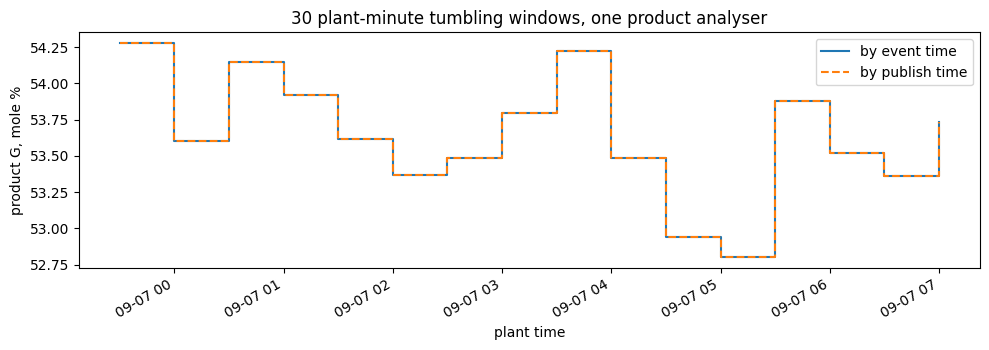

In [20]:
import matplotlib.pyplot as plt

w = tumbling("XMEAS_40_product_G")
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.step(w.index, w["by event time"], where="post", label="by event time")
ax.step(w.index, w["by publish time"], where="post", label="by publish time",
        linestyle="--")
ax.set_xlabel("plant time")
ax.set_ylabel("product G, mole %")
ax.set_title("30 plant-minute tumbling windows, one product analyser")
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()

## What this session leaves you with

The feed kept nearly every promise the contract made, and the data still was not fit
to average. Those are separate questions, and separating them is most of what a
validation suite is for: `feed_schema` catches a publisher that has gone wrong,
`clean_schema` catches an assumption the next stage was about to make.

The four failures this notebook found are the ones that recur on any real instrument
feed. A status code that says the device does not trust its own number, which no
amount of looking at the number will reveal. A held value republished on a timer,
which inflates every count taken over the raw rows. And data that arrives after the
window it belongs to has closed, which is why the aggregate has to be computed in
event time and why a watermark is a deadline rather than a fact. And a wide table
that is a fifth empty the moment you pivot, because the tags are not sampled on a
common grid, which every method defined over complete cases will run into first.

Assignment **A3** collects from this same plant, for longer, and asks you to build the
pipeline properly: a contract-generated schema, a quarantine you can defend, a filled
sample grid that records which of its numbers you invented, and a windowed aggregate
whose lateness policy you have to state and justify.
